# Few-Shot Personalization for Consistent Character Generation — Colab Cloud Runbook (A100)

Runs the 24-cell experiment grid (TI vs DB-LoRA × {3,5,10,20} shots × 3 trials) on a Colab cloud A100.

**Order of operations:**
1. §1 — confirm GPU.
2. §2 — upload the project zip and `cd` into it.
3. §3 — mount Drive so checkpoints survive 12-hour session timeouts.
4. §4 onward — install deps, clone diffusers, run experiments.

## 1. GPU sanity check

In [4]:
import os, sys, subprocess, torch
from pathlib import Path

# If we're already inside the project, stay; otherwise we'll cd in §2.
if Path('configs/ti_sdxl.yaml').exists():
    print('CWD already in project root:', Path.cwd())
elif Path('/content/genfinal_proj/configs/ti_sdxl.yaml').exists():
    os.chdir('/content/genfinal_proj')
    print('chdir -> /content/genfinal_proj')
else:
    print('CWD:', Path.cwd(), '(project not yet uploaded — see §2)')

print('python :', sys.version.split()[0])
print('torch  :', torch.__version__)
print('cuda   :', torch.version.cuda)
print('cuda available:', torch.cuda.is_available())
if torch.cuda.is_available():
    print('device :', torch.cuda.get_device_name(0))
    free, total = torch.cuda.mem_get_info()
    print(f'vram   : {free/1e9:.1f} GB free / {total/1e9:.1f} GB total')
    try:
        out = subprocess.check_output(['nvidia-smi'], text=True)
        print('\n' + out.split('\n\n')[0])
    except Exception as e:
        print('nvidia-smi not on PATH:', e)
else:
    raise SystemExit('No CUDA GPU detected — switch runtime to GPU.')

CWD: /content (project not yet uploaded — see §2)
python : 3.12.13
torch  : 2.10.0+cu128
cuda   : 12.8
cuda available: True
device : NVIDIA A100-SXM4-80GB
vram   : 84.6 GB free / 85.1 GB total

Mon May  4 16:39:18 2026       
+-----------------------------------------------------------------------------------------+
| NVIDIA-SMI 580.82.07              Driver Version: 580.82.07      CUDA Version: 13.0     |
+-----------------------------------------+------------------------+----------------------+
| GPU  Name                 Persistence-M | Bus-Id          Disp.A | Volatile Uncorr. ECC |
| Fan  Temp   Perf          Pwr:Usage/Cap |           Memory-Usage | GPU-Util  Compute M. |
|                                         |                        |               MIG M. |
|=========================================+========================+======================|
|   0  NVIDIA A100-SXM4-80GB          Off |   00000000:00:05.0 Off |                    0 |
| N/A   33C    P0             64W /  4

## 2. Clone the project from GitHub and `cd` into it

Clones [yuzukaR/Gen_Finalproj](https://github.com/yuzukaR/Gen_Finalproj) into `/content/genfinal_proj`. Skips the clone on subsequent cell runs in the same session. To pick up changes you've pushed to GitHub later, use the `git pull` cell after §3.

In [11]:
import os, shutil, subprocess
from pathlib import Path

REPO_URL = 'https://github.com/yuzukaR/Gen_Finalproj.git'
PROJECT_DIR = Path('/content/genfinal_proj')

if (PROJECT_DIR / '.git').exists():
    print('git checkout already at', PROJECT_DIR)
else:
    if PROJECT_DIR.exists():
        # Came from a previous (non-git) unzip — back it up before cloning fresh.
        backup = PROJECT_DIR.with_suffix('.preclone_backup')
        if backup.exists():
            shutil.rmtree(backup)
        shutil.move(str(PROJECT_DIR), str(backup))
        print(f'moved old non-git tree -> {backup}')
    subprocess.check_call(['git', 'clone', '--depth', '1', REPO_URL, str(PROJECT_DIR)])

os.chdir(PROJECT_DIR)
print('CWD:', Path.cwd())
print('contents:', sorted(p.name for p in Path('.').iterdir())[:20])

git checkout already at /content/genfinal_proj
CWD: /content/genfinal_proj
contents: ['.git', '.gitignore', 'CS5788_Project_Proposal_Template.pdf', 'README.md', 'configs', 'data', 'notebooks', 'plan.md', 'project-guidelines.pdf', 'requirements.txt', 'results', 'scripts', 'sitecustomize.py', 'src']


## 3. Mount Drive and persist heavy outputs

Symlinks `results/checkpoints/`, `results/samples/`, and `data/prior/` into Drive so checkpoints, samples, and the 200 prior images survive session timeouts. `results/figures/`, `data/clean/`, and `data/splits/` stay in the repo checkout.

In [12]:
import os, shutil
from pathlib import Path
from google.colab import drive

drive.mount('/content/drive')
DRIVE_ROOT = Path('/content/drive/MyDrive/genfinal_proj_outputs')
DRIVE_ROOT.mkdir(parents=True, exist_ok=True)

results_root = Path('results')
legacy_results = results_root.is_symlink()
if legacy_results:
    print('migrating legacy results/ symlink -> results/checkpoints + results/samples symlinks')
    results_root.unlink()

results_root.mkdir(parents=True, exist_ok=True)
(results_root / 'figures').mkdir(parents=True, exist_ok=True)
(results_root / 'figures' / '.gitkeep').touch(exist_ok=True)

for sub in ['results/checkpoints', 'results/samples', 'data/prior']:
    local = Path(sub)
    drive_dst = DRIVE_ROOT / sub
    drive_dst.mkdir(parents=True, exist_ok=True)
    if local.exists() and not local.is_symlink():
        has_files = any(local.rglob('*')) if local.is_dir() else True
        if has_files:
            backup = local.with_suffix('.local_backup')
            print(f'moving non-empty {local} -> {backup}')
            if backup.exists():
                if backup.is_dir() and not backup.is_symlink():
                    shutil.rmtree(backup)
                else:
                    backup.unlink()
            shutil.move(str(local), str(backup))
        else:
            if local.is_dir():
                shutil.rmtree(local)
            else:
                local.unlink()
    local.parent.mkdir(parents=True, exist_ok=True)
    if not local.exists():
        os.symlink(drive_dst.resolve(), local)
    print(f'{local} -> {os.readlink(local)}')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
results/checkpoints -> /content/drive/MyDrive/genfinal_proj_outputs/results/checkpoints
results/samples -> /content/drive/MyDrive/genfinal_proj_outputs/results/samples
data/prior -> /content/drive/MyDrive/genfinal_proj_outputs/data/prior


### Optional — pull the latest changes from GitHub

Run this cell whenever you've pushed updates to `yuzukaR/Gen_Finalproj` and want them reflected in this Colab session. It now **skips the update if the working tree is dirty** so local fixes in `/content/genfinal_proj/` are not overwritten. Edit on your Mac -> `git push` -> run this cell.

In [13]:
import os, shutil, subprocess
from pathlib import Path

PROJECT_DIR = Path('/content/genfinal_proj')
DRIVE_ROOT = Path('/content/drive/MyDrive/genfinal_proj_outputs')
assert (PROJECT_DIR / '.git').exists(), 'project is not a git checkout — re-run §2'

def git(*args):
    """Run a git command, return stdout, raise on failure."""
    return subprocess.check_output(['git', '-C', str(PROJECT_DIR), *args], text=True).strip()

def repair_legacy_results_layout():
    results_root = PROJECT_DIR / 'results'
    if not results_root.is_symlink():
        return False
    print('repairing legacy results/ symlink before sync ...')
    results_root.unlink()
    results_root.mkdir(parents=True, exist_ok=True)
    (results_root / 'figures').mkdir(parents=True, exist_ok=True)
    (results_root / 'figures' / '.gitkeep').touch(exist_ok=True)
    for sub in ['results/checkpoints', 'results/samples']:
        local = PROJECT_DIR / sub
        drive_dst = DRIVE_ROOT / sub
        drive_dst.mkdir(parents=True, exist_ok=True)
        if local.exists() and not local.is_symlink():
            if local.is_dir():
                shutil.rmtree(local)
            else:
                local.unlink()
        os.symlink(drive_dst.resolve(), local)
    return True

before = git('log', '-1', '--oneline')
print('before sync:', before)

repair_legacy_results_layout()
dirty_lines = [line for line in git('status', '--porcelain').splitlines() if line.strip()]
benign_untracked = {'?? results.local_backup/', '?? data/prior.local_backup/'}
meaningful_dirty = [line for line in dirty_lines if line not in benign_untracked]
if meaningful_dirty:
    print('\nworking tree has local changes; skipping auto-update to avoid overwriting them:')
    print('\n'.join(meaningful_dirty))
else:
    print('\nfetching origin/main ...')
    print(git('fetch', 'origin', 'main'))
    print(git('merge', '--ff-only', 'origin/main'))

after = git('log', '-1', '--oneline')
print('\nafter sync:', after)

if before == after:
    print('\n(no new commits — already at latest or update skipped)')

# Sanity-check that the CLIP fix is on disk.
print('\nclip_alignment.py CLIPModel/AutoModel lines:')
print(subprocess.check_output(
    ['grep', '-n', '-E', 'from transformers|CLIPModel|AutoModel',
     str(PROJECT_DIR / 'src/eval/clip_alignment.py')], text=True))


before sync: b20b5de change torchao

working tree has local changes; skipping auto-update to avoid overwriting them:
?? configs/_sweep_dblora_rank16.yaml
?? results/checkpoints
?? results/samples
?? results/sweep/

after sync: b20b5de change torchao

(no new commits — already at latest or update skipped)

clip_alignment.py CLIPModel/AutoModel lines:
42:    # Use CLIPModel/CLIPProcessor explicitly. Some environments still surface
46:    from transformers import CLIPModel, CLIPProcessor  # lazy
51:    model = CLIPModel.from_pretrained(args.model).to(device).eval()



In [14]:
import os, shutil, subprocess
from pathlib import Path

PROJECT_DIR = Path('/content/genfinal_proj')
DRIVE_ROOT = Path('/content/drive/MyDrive/genfinal_proj_outputs')
assert (PROJECT_DIR / '.git').exists(), 'project is not a git checkout — re-run §2'

def git(*args, check=True):
    proc = subprocess.run(
        ['git', '-C', str(PROJECT_DIR), *args],
        text=True,
        capture_output=True,
    )
    if check and proc.returncode != 0:
        raise RuntimeError(proc.stderr or proc.stdout)
    return proc.stdout.strip()

def is_tracked(relpath: str) -> bool:
    proc = subprocess.run(
        ['git', '-C', str(PROJECT_DIR), 'ls-files', '--error-unmatch', relpath],
        text=True,
        capture_output=True,
    )
    return proc.returncode == 0

def repair_legacy_results_layout():
    results_root = PROJECT_DIR / 'results'
    if results_root.is_symlink():
        print('repairing legacy results/ symlink before sync ...')
        results_root.unlink()
        results_root.mkdir(parents=True, exist_ok=True)
        (results_root / 'figures').mkdir(parents=True, exist_ok=True)
        (results_root / 'figures' / '.gitkeep').touch(exist_ok=True)

    for sub in ['results/checkpoints', 'results/samples']:
        local = PROJECT_DIR / sub
        drive_dst = DRIVE_ROOT / sub
        drive_dst.mkdir(parents=True, exist_ok=True)
        if local.exists() or local.is_symlink():
            if local.is_symlink() or local.is_file():
                local.unlink()
            elif local.is_dir():
                shutil.rmtree(local)
        os.symlink(drive_dst.resolve(), local)

def remove_legacy_temp_sweep_configs():
    for path in PROJECT_DIR.glob('configs/_sweep_dblora_rank*.yaml'):
        rel = path.relative_to(PROJECT_DIR).as_posix()
        if not is_tracked(rel):
            print('removing legacy temp config:', rel)
            path.unlink()

def is_benign_status(line: str) -> bool:
    path = line[3:]
    return (
        path == 'results.local_backup/' or
        path == 'data/prior.local_backup/' or
        path.startswith('results/checkpoints') or
        path.startswith('results/samples') or
        path.startswith('results/sweep')
    )

before = git('log', '-1', '--oneline')
print('before sync:', before)

repair_legacy_results_layout()
remove_legacy_temp_sweep_configs()

print('\nfetching origin/main ...')
print(git('fetch', 'origin', 'main'))

dirty_lines = [line for line in git('status', '--porcelain').splitlines() if line.strip()]
meaningful_dirty = [line for line in dirty_lines if not is_benign_status(line)]

if meaningful_dirty:
    print('\nworking tree has real local changes; skipping auto-update:')
    print('\n'.join(meaningful_dirty))
    pending = git('log', '--oneline', 'HEAD..origin/main', check=False)
    if pending:
        print('\nremote commits waiting:')
        print(pending)
else:
    print(git('merge', '--ff-only', 'origin/main'))

after = git('log', '-1', '--oneline')
print('\nafter sync:', after)

print('\nclip_alignment.py CLIPModel/CLIPProcessor lines:')
print(subprocess.check_output(
    ['grep', '-n', '-E', 'from transformers|CLIPModel|CLIPProcessor',
     str(PROJECT_DIR / 'src/eval/clip_alignment.py')],
    text=True
))

before sync: b20b5de change torchao
removing legacy temp config: configs/_sweep_dblora_rank16.yaml

fetching origin/main ...

Updating b20b5de..c6ef433
Fast-forward
 README.md                         |     9 +
 configs/_sweep_dblora_rank16.yaml |    35 +
 configs/_sweep_dblora_rank32.yaml |    35 +
 configs/_sweep_dblora_rank64.yaml |    35 +
 notebooks/run_pipeline.ipynb      | 13311 +++++++++++++++---------------------
 src/train/_launch.py              |    37 +
 src/train/dreambooth_lora.py      |    17 +-
 src/train/textual_inversion.py    |    17 +-
 8 files changed, 5579 insertions(+), 7917 deletions(-)
 create mode 100644 configs/_sweep_dblora_rank16.yaml
 create mode 100644 configs/_sweep_dblora_rank32.yaml
 create mode 100644 configs/_sweep_dblora_rank64.yaml

after sync: c6ef433 fix error

clip_alignment.py CLIPModel/CLIPProcessor lines:
42:    # Use CLIPModel/CLIPProcessor explicitly. Some environments still surface
46:    from transformers import CLIPModel, CLIPProcessor  

## 4. Install dependencies

`requirements.txt` pins diffusers to GitHub HEAD (the SDXL example scripts require a dev version) and pins `transformers / accelerate / peft` to versions diffusers main hard-requires at import time.

If you've already installed deps in this kernel session, do **Runtime → Restart session** before re-running so the new versions are picked up cleanly.

In [16]:
!pip install -q -r requirements.txt

from packaging.version import Version
import diffusers, transformers, accelerate, peft
print('diffusers   ', diffusers.__version__)
print('transformers', transformers.__version__)
print('accelerate  ', accelerate.__version__)
print('peft        ', peft.__version__)

if Version(transformers.__version__) >= Version('5.0.0'):
    raise SystemExit(
        'Installed transformers>=5.0, but this project requires transformers<5.0. '
        'Restart the runtime and reinstall dependencies before continuing.'
    )


  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.0/44.0 kB 4.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.0/12.0 MB 59.0 MB/s eta 0:00:0000:010:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 509.1/509.1 kB 41.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 3.3/3.3 MB 79.9 MB/s eta 0:00:00:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 60.7/60.7 MB 30.9 MB/s eta 0:00:0000:0100:01m
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 25.6 MB/s eta 0:00:00a 0:00:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 566.4/566.4 kB 41.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 44.8/44.8 kB 5.1 MB/s eta 0:00:00
diffusers    0.38.0.dev0
transformers 4.57.6
accelerate   1.13.0
peft         0.19.1


## 5. Clone diffusers and wire env vars

Our `src/train/*.py` modules shell out to the official diffusers training scripts.

In [17]:
import os, subprocess
from pathlib import Path

# Clone the diffusers repo only for its example training scripts (the package
# itself was already installed via requirements.txt).
DIFFUSERS_DIR = Path('/content/diffusers')
if not DIFFUSERS_DIR.exists():
    subprocess.check_call(['git', 'clone', '--depth', '1',
                            'https://github.com/huggingface/diffusers.git', str(DIFFUSERS_DIR)])

os.environ['DIFFUSERS_TI_SDXL_SCRIPT'] = str(DIFFUSERS_DIR / 'examples/textual_inversion/textual_inversion_sdxl.py')
os.environ['DIFFUSERS_DBLORA_SDXL_SCRIPT'] = str(DIFFUSERS_DIR / 'examples/dreambooth/train_dreambooth_lora_sdxl.py')
print('TI    script ->', os.environ['DIFFUSERS_TI_SDXL_SCRIPT'])
print('DB-LoRA script ->', os.environ['DIFFUSERS_DBLORA_SDXL_SCRIPT'])

# bf16 matches the configs and avoids the fp16 grad-scaler unscale bug + NaN loss.
subprocess.check_call(['accelerate', 'config', 'default', '--mixed_precision', 'bf16'])

for pkg in ('xformers', 'bitsandbytes'):
    try:
        __import__(pkg)
        print(f'{pkg}: available')
    except Exception as exc:
        print(f'{pkg}: unavailable ({exc})')


TI    script -> /content/diffusers/examples/textual_inversion/textual_inversion_sdxl.py
DB-LoRA script -> /content/diffusers/examples/dreambooth/train_dreambooth_lora_sdxl.py
xformers: available
bitsandbytes: available


## 6. Verify dataset is in place

A plain GitHub clone does not include your subject photos. This cell uses any existing `data/clean/*.png` and `data/splits/splits.json`; otherwise it preprocesses from `data/raw/` if you uploaded raw images there. If neither exists, it stops with a direct setup message.

In [28]:
from pathlib import Path
import json, subprocess, sys

clean_dir = Path('data/clean')
raw_dir = Path('data/raw')
splits_path = Path('data/splits/splits.json')
raw_exts = {'.jpg', '.jpeg', '.png', '.webp', '.bmp'}

clean_images = sorted(clean_dir.glob('*.png'))
raw_images = sorted(p for p in raw_dir.glob('*') if p.suffix.lower() in raw_exts)

if not clean_images:
    if raw_images:
        print(f'preprocessing {len(raw_images)} raw images from {raw_dir}/ ...')
        subprocess.check_call([
            sys.executable, '-m', 'src.data.preprocess',
            '--raw', str(raw_dir), '--out', str(clean_dir), '--size', '1024'
        ])
        clean_images = sorted(clean_dir.glob('*.png'))
    else:
        raise SystemExit(
            'No cleaned dataset found in data/clean/ and no raw images found in data/raw/. '
            'Upload your subject photos into data/raw/ or copy preprocessed PNGs into data/clean/ '
            'before running the training pipeline.'
        )

if not splits_path.exists():
    print('building data/splits/splits.json ...')
    subprocess.check_call([
        sys.executable, '-m', 'src.data.sampler',
        '--clean', str(clean_dir), '--out', str(splits_path)
    ])

with splits_path.open() as f:
    splits = json.load(f)

print(f'{len(clean_images)} cleaned PNGs in {clean_dir}/')
for trial, by_shot in splits['splits'].items():
    print(f'  {trial}:', {k: len(v) for k, v in by_shot.items()})

25 cleaned PNGs in data/clean/
  trial1: {'shots3': 3, 'shots5': 5, 'shots10': 10, 'shots20': 20}
  trial2: {'shots3': 3, 'shots5': 5, 'shots10': 10, 'shots20': 20}
  trial3: {'shots3': 3, 'shots5': 5, 'shots10': 10, 'shots20': 20}


## 7. Generate the class-prior set (one time, ~15 min on A100)

Only DB-LoRA needs this — used as a regularizer so the model doesn't forget what 'cat' means. Lives on Drive via the symlink, so it's a one-time cost.

In [9]:
from pathlib import Path
import subprocess

if len(list(Path('data/prior').glob('*.png'))) >= 200:
    print('data/prior already has >=200 images, skipping')
else:
    subprocess.check_call(['python', '-m', 'src.infer.generate',
                            '--mode', 'prior',
                            '--class_prompt', 'a photo of a cat',
                            '--num', '200',
                            '--out', 'data/prior'])

data/prior already has >=200 images, skipping


## 8. Smoke test — one TI + one DB-LoRA cell at shots=3, trial=trial1

Catches environment/path bugs before launching the full grid.

In [26]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
from PIL import Image as PILImage

PREFERRED_PROMPT_IDS = [
    'style_oil_painting',
    'scene_beach',
    'pose_running',
    'acc_hat',
]

def _read_json(path):
    path = Path(path)
    if not path.exists():
        return None
    with open(path, 'r') as f:
        return json.load(f)

def show_run_result(sample_dir, ckpt_dir=None, title=None, max_images=4, seed=11):
    sample_dir = Path(sample_dir)
    ckpt_dir = Path(ckpt_dir) if ckpt_dir is not None else None
    title = title or str(sample_dir)

    manifest = _read_json(sample_dir / 'manifest.json')
    dino = _read_json(sample_dir / 'dino.json')
    clip = _read_json(sample_dir / 'clip.json')
    stats = _read_json(ckpt_dir / 'run_stats.json') if ckpt_dir else None

    print(f'\n=== {title} ===')
    print('sample_dir:', sample_dir)
    if stats:
        print(
            f"train: {stats.get('elapsed_min', 0):.2f} min, "
            f"peak_vram: {stats.get('peak_vram_gb', 0):.2f} GB"
        )
    if dino:
        print(f"dino_identity_mean: {dino.get('dino_identity_mean', float('nan')):.4f}")
    if clip:
        print(f"clip_alignment_mean: {clip.get('clip_alignment_mean', float('nan')):.4f}")

    if not manifest or not manifest.get('items'):
        print('no manifest.json items found yet')
        return

    items = manifest['items']
    seed_items = [it for it in items if it.get('seed') == seed]
    if seed_items:
        items = seed_items

    picked = []
    seen_files = set()
    for pid in PREFERRED_PROMPT_IDS:
        for it in items:
            if it.get('prompt_id') == pid and it['file'] not in seen_files:
                picked.append(it)
                seen_files.add(it['file'])
                break
        if len(picked) >= max_images:
            break

    if len(picked) < max_images:
        for it in items:
            if it['file'] not in seen_files:
                picked.append(it)
                seen_files.add(it['file'])
            if len(picked) >= max_images:
                break

    n = len(picked)
    fig, axes = plt.subplots(1, n, figsize=(4 * n, 4))
    if n == 1:
        axes = [axes]

    for ax, it in zip(axes, picked):
        img = PILImage.open(sample_dir / it['file']).convert('RGB')
        ax.imshow(img)
        ax.set_title(f"{it.get('prompt_id', 'unknown')}\nseed={it.get('seed', '?')}", fontsize=10)
        ax.axis('off')

    fig.suptitle(title, fontsize=14)
    plt.tight_layout()
    plt.show()


In [27]:
import os, subprocess, sys
from pathlib import Path

def run(cmd):
    print('$', ' '.join(cmd), flush=True)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                             text=True, bufsize=1, env={**os.environ, 'PYTHONUNBUFFERED': '1'})
    for line in proc.stdout:
        sys.stdout.write(line); sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise subprocess.CalledProcessError(proc.returncode, cmd)

ckpt = Path('results/checkpoints/ti/shots3/trial1')
samp = Path('results/samples/ti/shots3/trial1')

if not ((ckpt / 'run_stats.json').exists() and (ckpt / 'learned_embeds.safetensors').exists()):
    run(['python', '-u', '-m', 'src.train.textual_inversion',
         '--config', 'configs/ti_sdxl.yaml',
         '--splits', 'data/splits/splits.json',
         '--trial', 'trial1', '--shots', '3', '--out', str(ckpt)])
else:
    print('[skip train] checkpoint already exists at', ckpt)

if not (samp / 'manifest.json').exists():
    run(['python', '-u', '-m', 'src.infer.generate',
         '--mode', 'ti', '--ckpt', str(ckpt),
         '--method_config', 'configs/ti_sdxl.yaml', '--out', str(samp)])
else:
    print('[skip generate]', samp / 'manifest.json', 'exists')

if not (samp / 'dino.json').exists():
    run(['python', '-u', '-m', 'src.eval.dino_identity',
         '--refs', 'data/clean', '--gens', str(samp), '--out', str(samp / 'dino.json')])
else:
    print('[skip dino]')

if not (samp / 'clip.json').exists():
    run(['python', '-u', '-m', 'src.eval.clip_alignment',
         '--gens', str(samp), '--strip', '<my-character>', '--out', str(samp / 'clip.json')])
else:
    print('[skip clip]')

show_run_result(
    samp,
    ckpt,
    title='TI smoke test: shots=3 trial1',
    max_images=4,
    seed=11,
)

$ python -u -m src.train.textual_inversion --config configs/ti_sdxl.yaml --splits data/splits/splits.json --trial trial1 --shots 3 --out results/checkpoints/ti/shots3/trial1
Launching: accelerate launch /content/diffusers/examples/textual_inversion/textual_inversion_sdxl.py --pretrained_model_name_or_path=stabilityai/stable-diffusion-xl-base-1.0 --train_data_dir=results/checkpoints/ti/shots3/trial1/_instance --placeholder_token=<my-character> --initializer_token=cat --num_vectors=1 --resolution=1024 --train_batch_size=1 --gradient_accumulation_steps=4 --max_train_steps=3000 --learning_rate=0.0005 --lr_scheduler=constant --lr_warmup_steps=0 --mixed_precision=bf16 --save_steps=500 --seed=1234 --output_dir=results/checkpoints/ti/shots3/trial1 --gradient_checkpointing --enable_xformers_memory_efficient_attention
Flax classes are deprecated and will be removed in Diffusers v1.0.0. We recommend migrating to PyTorch classes or pinning your version of Diffusers.
Flax classes are deprecated and

KeyboardInterrupt: 

In [22]:
from pathlib import Path
from PIL import Image
import numpy as np

samp = Path('results/samples/ti/shots3/trial1')
for p in sorted(samp.glob('*.png'))[:4]:
    arr = np.array(Image.open(p).convert('RGB'))
    print(p.name, arr.min(), arr.max(), arr.mean())

acc_bowtie_seed11.png 0 0 0.0
acc_bowtie_seed22.png 0 0 0.0
acc_bowtie_seed33.png 0 0 0.0
acc_bowtie_seed44.png 0 0 0.0


In [23]:
from pathlib import Path
import shutil

for p in [
    Path('results/checkpoints/ti/shots3/trial1'),
    Path('results/samples/ti/shots3/trial1'),
]:
    if p.exists():
        shutil.rmtree(p)

print('deleted stale TI smoke-test outputs')

deleted stale TI smoke-test outputs


[skip train] checkpoint already exists at results/checkpoints/dblora/shots3/trial1
[skip generate]
[skip dino]
[skip clip]

=== DB-LoRA smoke test: shots=3 trial1 ===
sample_dir: results/samples/dblora/shots3/trial1
train: 243.67 min, peak_vram: 0.00 GB
dino_identity_mean: 0.7740
clip_alignment_mean: 0.2220


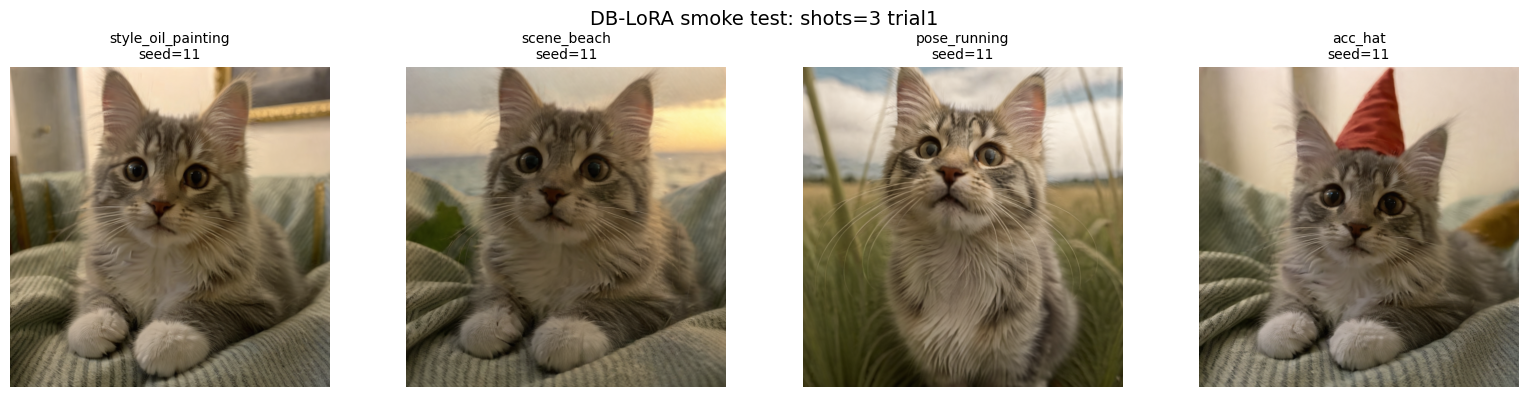

In [21]:
import os, subprocess, sys
from pathlib import Path

def run(cmd):
    print('$', ' '.join(cmd), flush=True)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                             text=True, bufsize=1, env={**os.environ, 'PYTHONUNBUFFERED': '1'})
    for line in proc.stdout:
        sys.stdout.write(line); sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise subprocess.CalledProcessError(proc.returncode, cmd)

ckpt = Path('results/checkpoints/dblora/shots3/trial1')
samp = Path('results/samples/dblora/shots3/trial1')

if not ((ckpt / 'run_stats.json').exists() and (ckpt / 'pytorch_lora_weights.safetensors').exists()):
    run(['python', '-u', '-m', 'src.train.dreambooth_lora',
         '--config', 'configs/dblora_sdxl.yaml',
         '--splits', 'data/splits/splits.json',
         '--prior', 'data/prior',
         '--trial', 'trial1', '--shots', '3', '--out', str(ckpt)])
else:
    print('[skip train] checkpoint already exists at', ckpt)

if not (samp / 'manifest.json').exists():
    run(['python', '-u', '-m', 'src.infer.generate',
         '--mode', 'dblora', '--ckpt', str(ckpt),
         '--method_config', 'configs/dblora_sdxl.yaml', '--out', str(samp)])
else:
    print('[skip generate]')

if not (samp / 'dino.json').exists():
    run(['python', '-u', '-m', 'src.eval.dino_identity',
         '--refs', 'data/clean', '--gens', str(samp), '--out', str(samp / 'dino.json')])
else:
    print('[skip dino]')

if not (samp / 'clip.json').exists():
    run(['python', '-u', '-m', 'src.eval.clip_alignment',
         '--gens', str(samp), '--strip', 'sks', '--out', str(samp / 'clip.json')])
else:
    print('[skip clip]')

show_run_result(
    samp,
    ckpt,
    title='DB-LoRA smoke test: shots=3 trial1',
    max_images=4,
    seed=11,
)

## 9. LoRA rank sweep on shots=5, trial=trial1

Sweeps `lora_rank ∈ {16, 32, 64}` to pick the best for the main grid. Outputs go under `results/sweep/dblora/rank{R}/` so the main grid namespace stays clean.

Composite score: `dino − 0.5 × (clip_drop_from_max)`.

Cost: ~1.5–3 GPU-hours total.

In [18]:
import json, os, subprocess, sys
from pathlib import Path
import yaml
import pandas as pd

def run(cmd):
    print('$', ' '.join(cmd), flush=True)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                             text=True, bufsize=1, env={**os.environ, 'PYTHONUNBUFFERED': '1'})
    for line in proc.stdout:
        sys.stdout.write(line); sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise subprocess.CalledProcessError(proc.returncode, cmd)

BASE_CFG = Path('configs/dblora_sdxl.yaml')
SWEEP_RANKS = [16, 32, 64]
TRIAL = 'trial1'
SHOTS = 5

results = []
for rank in SWEEP_RANKS:
    print(f'\n========== rank={rank} ==========')
    cfg = yaml.safe_load(open(BASE_CFG))
    cfg['lora_rank'] = rank
    cfg['lora_alpha'] = rank
    tmp_cfg = Path(f'configs/_sweep_dblora_rank{rank}.yaml')
    yaml.safe_dump(cfg, open(tmp_cfg, 'w'))

    ckpt = Path(f'results/sweep/dblora/rank{rank}/ckpt')
    samp = Path(f'results/sweep/dblora/rank{rank}/samples')

    run(['python', '-u', '-m', 'src.train.dreambooth_lora',
        '--config', str(tmp_cfg),
        '--splits', 'data/splits/splits.json',
        '--prior', 'data/prior',
        '--trial', TRIAL, '--shots', str(SHOTS),
        '--out', str(ckpt)])
    run(['python', '-u', '-m', 'src.infer.generate',
        '--mode', 'dblora', '--ckpt', str(ckpt),
        '--method_config', str(tmp_cfg), '--out', str(samp)])
    run(['python', '-u', '-m', 'src.eval.dino_identity',
        '--refs', 'data/clean', '--gens', str(samp),
        '--out', str(samp / 'dino.json')])
    run(['python', '-u', '-m', 'src.eval.clip_alignment',
        '--gens', str(samp), '--strip', 'sks',
        '--out', str(samp / 'clip.json')])

    dino = json.load(open(samp / 'dino.json'))['dino_identity_mean']
    clip_ = json.load(open(samp / 'clip.json'))['clip_alignment_mean']
    results.append({'rank': rank, 'dino': dino, 'clip': clip_})
    show_run_result(
        samp,
        ckpt,
        title=f'DB-LoRA rank sweep: rank={rank}',
        max_images=3,
        seed=11,
    )

df = pd.DataFrame(results)
df['composite'] = df['dino'] - 0.5 * (df['clip'].max() - df['clip'])
print('\n=== rank sweep summary ===')
print(df.to_string(index=False))
best = int(df.sort_values('composite', ascending=False).iloc[0]['rank'])
print(f'\nbest rank by composite: {best}')


========== rank=16 ==========
$ python -u -m src.train.dreambooth_lora --config configs/_sweep_dblora_rank16.yaml --splits data/splits/splits.json --prior data/prior --trial trial1 --shots 5 --out results/sweep/dblora/rank16/ckpt
Launching: accelerate launch /content/diffusers/examples/dreambooth/train_dreambooth_lora_sdxl.py --pretrained_model_name_or_path=stabilityai/stable-diffusion-xl-base-1.0 --instance_data_dir=results/sweep/dblora/rank16/ckpt/_instance --instance_prompt=a photo of sks cat --resolution=1024 --train_batch_size=1 --gradient_accumulation_steps=4 --max_train_steps=1500 --learning_rate=0.0001 --lr_scheduler=constant --lr_warmup_steps=0 --mixed_precision=bf16 --rank=16 --checkpointing_steps=750 --seed=1234 --output_dir=results/sweep/dblora/rank16/ckpt --gradient_checkpointing --enable_xformers_memory_efficient_attention --use_8bit_adam --with_prior_preservation --prior_loss_weight=1.0 --class_data_dir=data/prior --class_prompt=a photo of a cat --num_class_images=200
E

KeyboardInterrupt: 

In [ ]:
# Persist the chosen rank into configs/dblora_sdxl.yaml so the full grid uses it.
import yaml
BEST_RANK = best   # override here if you want, e.g. BEST_RANK = 32
cfg = yaml.safe_load(open('configs/dblora_sdxl.yaml'))
cfg['lora_rank'] = BEST_RANK
cfg['lora_alpha'] = BEST_RANK
yaml.safe_dump(cfg, open('configs/dblora_sdxl.yaml', 'w'))
print(f'configs/dblora_sdxl.yaml now uses lora_rank={BEST_RANK}')

## 10. Run the full 24-cell grid

Python loop with resume support — skips any cell whose `run_stats.json` and `clip.json` already exist. Safe to interrupt and re-run.

In [ ]:
import os, subprocess, sys
from pathlib import Path
from tqdm.auto import tqdm

def run(cmd):
    print('$', ' '.join(cmd), flush=True)
    proc = subprocess.Popen(cmd, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                             text=True, bufsize=1, env={**os.environ, 'PYTHONUNBUFFERED': '1'})
    for line in proc.stdout:
        sys.stdout.write(line); sys.stdout.flush()
    proc.wait()
    if proc.returncode != 0:
        raise subprocess.CalledProcessError(proc.returncode, cmd)

SHOTS = [3, 5, 10, 20]
TRIALS = ['trial1', 'trial2', 'trial3']

# Per-stage resume: only re-run a stage if its output is missing.
def stages_done(method, n, t):
    ckpt = Path(f'results/checkpoints/{method}/shots{n}/{t}')
    samp = Path(f'results/samples/{method}/shots{n}/{t}')
    train_marker = ckpt / ('learned_embeds.safetensors' if method == 'ti'
                            else 'pytorch_lora_weights.safetensors')
    return {
        'train':    (ckpt / 'run_stats.json').exists() and train_marker.exists(),
        'generate': (samp / 'manifest.json').exists(),
        'dino':     (samp / 'dino.json').exists(),
        'clip':     (samp / 'clip.json').exists(),
    }

def run_one(method, n, t):
    ckpt = f'results/checkpoints/{method}/shots{n}/{t}'
    samp = f'results/samples/{method}/shots{n}/{t}'
    done = stages_done(method, n, t)
    print('  done:', sorted(k for k, v in done.items() if v) or 'none')

    if not done['train']:
        if method == 'ti':
            run(['python', '-u', '-m', 'src.train.textual_inversion',
                '--config', 'configs/ti_sdxl.yaml',
                '--splits', 'data/splits/splits.json',
                '--trial', t, '--shots', str(n), '--out', ckpt])
        else:
            run(['python', '-u', '-m', 'src.train.dreambooth_lora',
                '--config', 'configs/dblora_sdxl.yaml',
                '--splits', 'data/splits/splits.json',
                '--prior', 'data/prior',
                '--trial', t, '--shots', str(n), '--out', ckpt])

    if not done['generate']:
        cfg = 'configs/ti_sdxl.yaml' if method == 'ti' else 'configs/dblora_sdxl.yaml'
        run(['python', '-u', '-m', 'src.infer.generate',
            '--mode', method, '--ckpt', ckpt,
            '--method_config', cfg, '--out', samp])

    if not done['dino']:
        run(['python', '-u', '-m', 'src.eval.dino_identity',
            '--refs', 'data/clean', '--gens', samp,
            '--out', f'{samp}/dino.json'])

    if not done['clip']:
        strip = '<my-character>' if method == 'ti' else 'sks'
        run(['python', '-u', '-m', 'src.eval.clip_alignment',
            '--gens', samp, '--strip', strip,
            '--out', f'{samp}/clip.json'])

cells = [(m, n, t) for n in SHOTS for t in TRIALS for m in ('ti', 'dblora')]
pbar = tqdm(cells, desc='grid', unit='cell')
for method, n, t in pbar:
    pbar.set_postfix_str(f'{method} shots={n} {t}')
    if all(stages_done(method, n, t).values()):
        print(f'[skip] {method} shots={n} {t}')
        show_run_result(
            f'results/samples/{method}/shots{n}/{t}',
            f'results/checkpoints/{method}/shots{n}/{t}',
            title=f'{method} shots={n} {t}',
            max_images=1,
            seed=11,
        )
        continue
    print(f'\n=== {method.upper()} shots={n} {t} ===')
    run_one(method, n, t)
    show_run_result(
        f'results/samples/{method}/shots{n}/{t}',
        f'results/checkpoints/{method}/shots{n}/{t}',
        title=f'{method} shots={n} {t}',
        max_images=1,
        seed=11,
    )
print('\nfull grid complete')

## 11. Aggregate metrics and plot

In [ ]:
import subprocess
import pandas as pd
from IPython.display import Image, display

subprocess.check_call(['python', '-m', 'src.eval.efficiency', '--out', 'results/metrics.csv'])
subprocess.check_call(['python', '-m', 'src.eval.plot', '--csv', 'results/metrics.csv', '--out', 'results/figures'])

df = pd.read_csv('results/metrics.csv')
summary = df.groupby(['method', 'shots'])[['dino_identity', 'clip_alignment',
                                            'elapsed_min', 'peak_vram_gb']].mean().round(3)
display(summary)
for f in ['identity_vs_shots.png', 'clip_vs_shots.png', 'identity_vs_clip.png',
          'time_vs_shots.png', 'vram_vs_shots.png']:
    display(Image(f'results/figures/{f}'))

## 12. Qualitative comparison grid for the report

In [ ]:
from pathlib import Path
from PIL import Image as PImage
import matplotlib.pyplot as plt

PROMPT_IDS = ['style_oil_painting', 'scene_beach', 'pose_running', 'acc_hat']
SEED = 11
SHOTS = [3, 5, 10, 20]
METHODS = ['ti', 'dblora']
TRIAL = 'trial1'

fig, axes = plt.subplots(len(PROMPT_IDS) * len(METHODS), len(SHOTS),
                          figsize=(3 * len(SHOTS), 3 * len(PROMPT_IDS) * len(METHODS)))
for i, pid in enumerate(PROMPT_IDS):
    for k, m in enumerate(METHODS):
        row = i * len(METHODS) + k
        for j, n in enumerate(SHOTS):
            ax = axes[row, j]
            p = Path(f'results/samples/{m}/shots{n}/{TRIAL}/{pid}_seed{SEED}.png')
            if p.exists():
                ax.imshow(PImage.open(p))
            ax.set_xticks([]); ax.set_yticks([])
            if j == 0:
                ax.set_ylabel(f'{pid}\n{m}', fontsize=8)
            if row == 0:
                ax.set_title(f'{n} shots')
fig.tight_layout()
fig.savefig('results/figures/qualitative_grid.png', dpi=120)
plt.show()